<a href="https://colab.research.google.com/github/Prithiviraj77MF/Quant-Research/blob/main/VaR_Historic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

In [17]:
tickers = ['CL=F','NG=F','GC=F','SI=F']
years = 5
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days= 365*years)

In [18]:
adj_close_df = pd.DataFrame()
data = yf.download(tickers, start=startDate, end=endDate)
adj_close_df = data['Close']
print(adj_close_df)

/tmp/ipykernel_563/3516280467.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=startDate, end=endDate)
[*********************100%***********************]  4 of 4 completed

Ticker           CL=F         GC=F   NG=F       SI=F
Date                                                
2021-03-15  65.389999  1728.900024  2.484  26.253000
2021-03-16  64.800003  1730.599976  2.562  25.974001
2021-03-17  64.599998  1726.800049  2.528  26.030001
2021-03-18  60.000000  1732.199951  2.481  26.320999
2021-03-19  61.419998  1741.400024  2.535  26.292000
...               ...          ...    ...        ...
2026-03-09  94.769997  5091.500000  3.120  84.031998
2026-03-10  83.449997  5229.700195  3.020  89.083000
2026-03-11  87.250000  5167.399902  3.209  85.065002
2026-03-12  95.730003  5115.799805  3.233  84.669998
2026-03-13  94.610001  5096.500000  3.156  82.714996

[1259 rows x 4 columns]


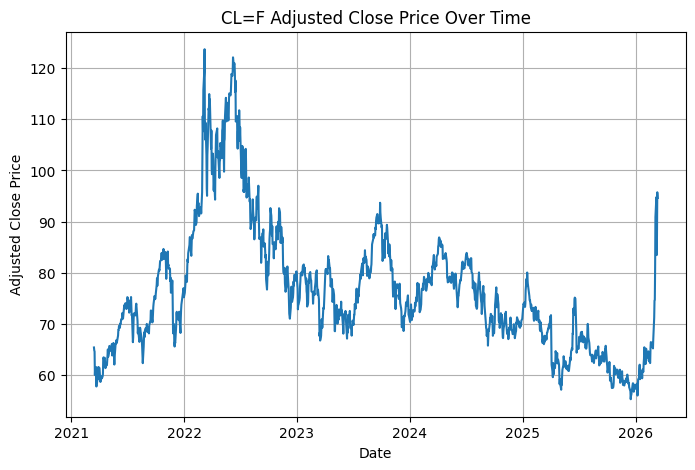

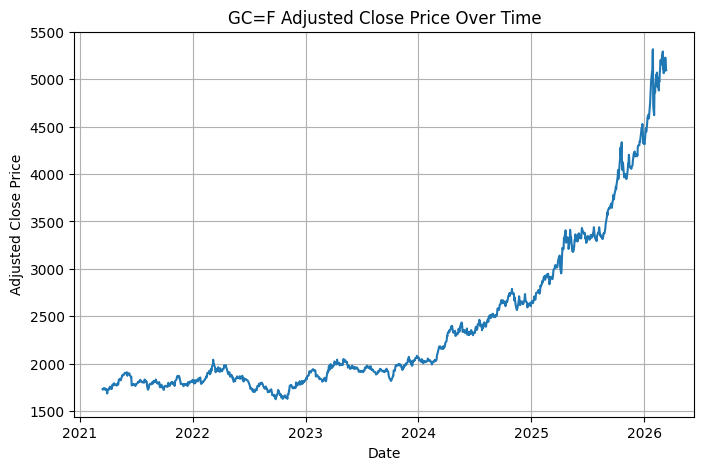

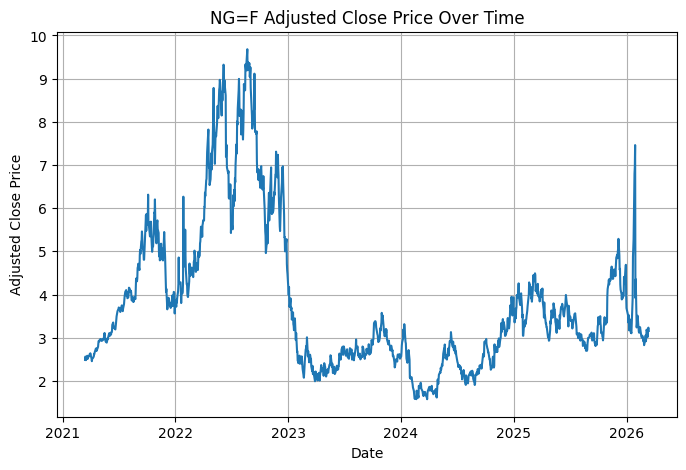

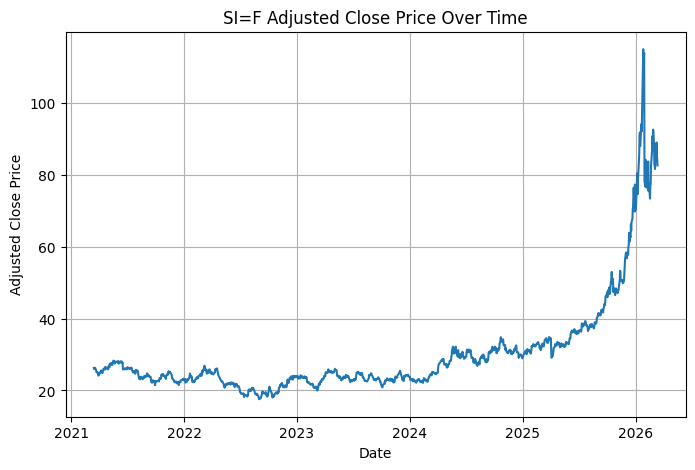

In [19]:
for ticker in adj_close_df.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(adj_close_df[ticker])
    plt.title(f'{ticker} Adjusted Close Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close Price')
    plt.grid(True)
    plt.show()

In [20]:
portfolio_value = 1000000
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)

[0.25 0.25 0.25 0.25]


In [21]:
log_returns = np.log(adj_close_df / adj_close_df.shift(1))
log_returns = log_returns.dropna()
log_returns

Ticker,CL=F,GC=F,NG=F,SI=F
Date,,,,
2021-03-16,-0.009064,0.000983,0.030918,-0.010684
2021-03-17,-0.003091,-0.002198,-0.013360,0.002154
2021-03-18,-0.073870,0.003122,-0.018767,0.011117
2021-03-19,0.023391,0.005297,0.021532,-0.001102
2021-03-22,0.002114,-0.002069,0.018371,-0.021180
...,...,...,...,...
2026-03-09,0.041693,-0.010667,-0.020933,0.002574
2026-03-10,-0.127205,0.026781,-0.032576,0.058371
2026-03-11,0.044530,-0.011984,0.060703,-0.046153


In [22]:
portfolio_returns = (log_returns.dot(weights))
portfolio_returns

,0
Date,
2021-03-16,0.003038
2021-03-17,-0.004124
2021-03-18,-0.019599
2021-03-19,0.012279
2021-03-22,-0.000691
...,...
2026-03-09,0.003167
2026-03-10,-0.018657
2026-03-11,0.011774


In [23]:
portfolio_mean = portfolio_returns.mean()
portfolio_std = portfolio_returns.std()
print(f"Portfolio Mean = {portfolio_mean}")
print(f"Portfolio Std. dev = {portfolio_std}")

Portfolio Mean = 0.000565242523128915
Portfolio Std. dev = 0.017767972071116158


In [24]:
days = 1
range_returns = portfolio_returns.rolling(window = days).sum()
range_returns = range_returns.dropna()
range_returns

,0
Date,
2021-03-16,0.003038
2021-03-17,-0.004124
2021-03-18,-0.019599
2021-03-19,0.012279
2021-03-22,-0.000691
...,...
2026-03-09,0.003167
2026-03-10,-0.018657
2026-03-11,0.011774


In [27]:
confidence_interval = np.array([0.90, 0.95, 0.99])
VaR = -np.percentile(range_returns, (1 - confidence_interval) * 100)*100
VaR1 = -np.percentile(range_returns,
 (1 - confidence_interval) * 100) * portfolio_value

for i, ci in enumerate(confidence_interval):
      print(f"VaR % for {days} days at {ci*100:.0f}% confidence: {VaR[i]:.5f}%")
for i, ci in enumerate(confidence_interval):
      print(f"VaR for {days} days at {ci*100:.0f}% confidence: {VaR1[i]:.3f}")

VaR % for 1 days at 90% confidence: 1.92557%
VaR % for 1 days at 95% confidence: 2.62867%
VaR % for 1 days at 99% confidence: 4.27220%
VaR for 1 days at 90% confidence: 19255.688
VaR for 1 days at 95% confidence: 26286.731
VaR for 1 days at 99% confidence: 42722.003


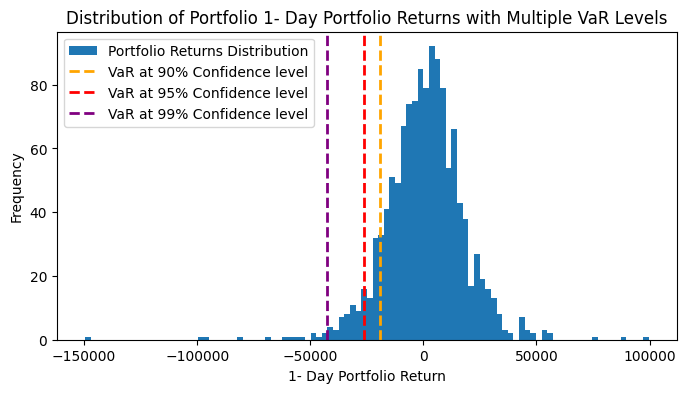

In [26]:
range_returns_value = range_returns * portfolio_value
plt.figure(figsize=(8, 4))
plt.hist(range_returns_value.dropna().values.flatten(),
         bins=100, label='Portfolio Returns Distribution')
plt.xlabel(f'{days}- Day Portfolio Return')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}- Day Portfolio Returns with Multiple VaR Levels')
colors = ['orange', 'red', 'purple']
for idx, ci in enumerate(confidence_interval):
    plt.axvline(-VaR1[idx], linestyle='dashed',
                linewidth=2, color=colors[idx],
                label=f'VaR at {ci*100:.0f}% Confidence level')

plt.legend()
plt.show()